# LSTM Validation on 2025 Backblaze Data — ST8000NM0055

This notebook validates the LSTM-based HDD failure prediction method on the 2025 Backblaze dataset for the **ST8000NM0055** drive model, which was also present in the original 2020 training data. The goal is to assess **temporal robustness**: does the same method, applied with the same architecture and hyperparameters, still work on the same hardware five years later?

**Methodology notes:**
- Same SMART attributes as the original work: `smart_5_raw`, `smart_187_raw`, `smart_188_raw`, `smart_197_raw`, `smart_198_raw`
- Same LSTM architecture: 3 stacked LSTM layers (128 units), dropout 0.4, L2 regularisation
- Same SMOTE-based class balancing, same SGD optimiser, same training settings
- **Train/test split**: chronological. Q1+Q2 2025 → train, Q3 2025 → test. This reflects deployment conditions, where future failures must be predicted from past telemetry.

In [3]:
import pandas as pd
import numpy as np

import sys
import glob
import os

import datetime
import time
import gc
import math
import random
from random import shuffle, randrange

from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.metrics import *

import matplotlib.pyplot as plt
#import seaborn as sns

In [ ]:

# Expect: [PhysicalDevice(name='/physical_device:CPU:0', ...),
#          PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

2.19.1
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import warnings
import tensorflow as tf

warnings.simplefilter(action='ignore', category=FutureWarning)

print("TensorFlow version:", tf.__version__)
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("Available devices:")
print(tf.config.list_physical_devices())

TensorFlow version: 2.21.0
Available devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Step 1 — Extract ST8000NM0055 from the 2025 combined parquet

Streams the combined Q1–Q3 2025 parquet and writes out only the ST8000NM0055 rows. Memory-safe — never holds more than one batch in RAM. Expected output: ~3.65M rows, 235 failures.

In [4]:
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.compute as pc

# UPDATE THESE PATHS FOR YOUR ENVIRONMENT
combined_parquet = '/Users/danielabutu/Desktop/AI and ML file/HDD journals/train_Q1_Q3_2025.parquet'
drive_parquet    = '/Users/danielabutu/Desktop/AI and ML file/HDD journals/ST8000NM0055_2025.parquet'
file_directory   = '/Users/danielabutu/Desktop/AI and ML file/HDD journals/validation_2025'
os.makedirs(file_directory, exist_ok=True)

TARGET_MODEL = 'ST8000NM0055'

if os.path.exists(drive_parquet):
    print(f"Already extracted: {drive_parquet}")
else:
    pf = pq.ParquetFile(combined_parquet)
    writer = None
    total_rows = 0
    total_failures = 0
    try:
        for batch in pf.iter_batches(batch_size=200_000):
            table = pa.Table.from_batches([batch])
            mask = pc.equal(table['model'], TARGET_MODEL)
            filtered = table.filter(mask)
            if filtered.num_rows == 0:
                continue
            if writer is None:
                writer = pq.ParquetWriter(drive_parquet, filtered.schema, compression='snappy')
            writer.write_table(filtered)
            total_rows += filtered.num_rows
            total_failures += int(pc.sum(filtered['failure']).as_py() or 0)
    finally:
        if writer is not None:
            writer.close()
    print(f"Extracted {total_rows:,} rows, {total_failures} failures to {drive_parquet}")

Already extracted: /Users/danielabutu/Desktop/AI and ML file/HDD journals/ST8000NM0055_2025.parquet


## Step 2 — Chronological train/test split

Q1+Q2 2025 → training, Q3 2025 → test. This mirrors how the model would be deployed: trained on past telemetry, evaluated on future telemetry.

In [5]:
# Load the ST8000NM0055 parquet (only ~3.65M rows, fits in memory)
df_all = pd.read_parquet(drive_parquet)
df_all['date'] = pd.to_datetime(df_all['date'])
print('Full ST8000NM0055 2025 shape:', df_all.shape)
print('Date range:', df_all['date'].min().date(), 'to', df_all['date'].max().date())
print('Total failures:', int(df_all['failure'].sum()))

# Chronological split: Q1+Q2 train, Q3 test
train_end = pd.Timestamp('2025-06-30')
df_train = df_all[df_all['date'] <= train_end].copy().reset_index(drop=True)
df_test  = df_all[df_all['date'] >  train_end].copy().reset_index(drop=True)

del df_all
gc.collect()

print('\nTrain (Q1+Q2 2025):', df_train.shape, '|', int(df_train['failure'].sum()), 'failures')
print('Test  (Q3 2025)   :', df_test.shape,  '|', int(df_test['failure'].sum()),  'failures')

Full ST8000NM0055 2025 shape: (3652408, 197)
Date range: 2025-01-01 to 2025-09-30
Total failures: 235

Train (Q1+Q2 2025): (2427968, 197) | 182 failures
Test  (Q3 2025)   : (1224440, 197) | 53 failures


In [6]:
print(df_train.model.value_counts())

model
ST8000NM0055    2427968
Name: count, dtype: int64


In [7]:
# Failed disks in training data
df_train.failure.value_counts()

failure
0    2427786
1        182
Name: count, dtype: int64

In [8]:
# Failed disks in test data
df_test.failure.value_counts()

failure
0    1224387
1         53
Name: count, dtype: int64

The data is highly imbalanced as there are far more healthy drive-day records than failure events. We use SMOTE to balance it later, mirroring the original methodology.

## Removing normalized columns and features not valid for the model

In [9]:
def prepare_dataframe(df):
    print("Removing unnecessary columns")

    # Drop all normalized columns
    cols = [c for c in df.columns if c.lower().find("normalized") != -1]
    df = df.drop(columns=cols)

    # Drop model and capacity columns (not used for training)
    drop_extra = [c for c in ['model', 'capacity_bytes'] if c in df.columns]
    df = df.drop(columns=drop_extra)

    # Convert string dates to datetime
    df['date'] = pd.to_datetime(df['date'])

    # Sort by serial number and date for sequence creation
    print("Sorting the data frame based on serial number and date")
    df = df.sort_values(by=['serial_number', 'date'], axis=0, ascending=True)
    df = df.reset_index(drop=True)

    # Ensure no NaNs
    df = df.fillna(0)

    return df

In [10]:
print("Processing train set...")
df_train = prepare_dataframe(df_train)

print("")
print("Processing test set...")
df_test = prepare_dataframe(df_test)

Processing train set...
Removing unnecessary columns
Sorting the data frame based on serial number and date

Processing test set...
Removing unnecessary columns
Sorting the data frame based on serial number and date


In [11]:
df_train.shape

(2427968, 102)

In [12]:
df_test.shape

(1224440, 102)

# Create sequences from datasets

In [13]:
# Return serial numbers of good (normal) and bad (failed) disks
def get_disk_serials(df, num_disks):
    failed_serials = df[df['failure'] == 1]['serial_number'].unique().tolist()

    # Normal disks = all serials that never failed in this period
    df_tmp = df[~df.serial_number.isin(failed_serials)]
    normal_serials = df_tmp.serial_number.value_counts()[:num_disks].index.tolist()

    print('Normal Disk Serials:', len(normal_serials))
    print('Failed Disk Serials:', len(failed_serials))

    return normal_serials, failed_serials

# Adjusting dates to fill any gaps in the time series

In [14]:
def adjust_dates(df_loc):
    """Fill any missing days for a single drive's time series.

    Note: collects rows into a list and concats once at the end, rather than
    concat-in-loop (O(n^2)). Bug fix vs the original; methodology unchanged.
    """
    col_list = df_loc.columns.tolist()
    cur_dates = df_loc['date'].values

    # Days between last and first record for this drive
    num_date_range = int((cur_dates[-1] - cur_dates[0]) / np.timedelta64(1, 'D')) + 1

    if num_date_range > len(cur_dates):
        pieces = []
        i_low = 0
        for i in range(len(cur_dates) - 1):
            diff_days = int((cur_dates[i+1] - cur_dates[i]) / np.timedelta64(1, 'D'))
            if diff_days > 1:
                pieces.append(df_loc.iloc[i_low:i+1])
                tmp_dates = [cur_dates[i] + np.timedelta64(x, 'D') for x in range(1, diff_days)]
                tmp_array = np.empty((len(tmp_dates), len(col_list)))
                tmp_array[:] = np.nan
                df_add = pd.DataFrame(tmp_array, columns=col_list)
                df_add['date'] = tmp_dates
                pieces.append(df_add)
                i_low = i + 1
        pieces.append(df_loc.iloc[i_low:])
        df_mod = pd.concat(pieces, ignore_index=True)
        # Forward-fill the inserted NaN rows. Original used method='ffill' (deprecated);
        # .ffill() is the modern equivalent. Behaviour identical.
        df_mod = df_mod.ffill()
    else:
        df_mod = df_loc.copy()

    return df_mod

This routine fills in missing days to ensure consistent sequences.

In [15]:
def fix_date_gaps(df, normal_serials=None, failed_serials=None):
    df_list = []
    serials_list = normal_serials + failed_serials
    for cur_serial in serials_list:
        adjusted_df = adjust_dates(df[df['serial_number'] == cur_serial])
        df_list.append(adjusted_df)
    df_fixed = pd.concat(df_list, ignore_index=True)
    return df_fixed

Build failed sequences by finding the failure, going back `lookahead` days, and taking the previous `sequence_length` days as the sample.

In [16]:
def create_normal_sequences(df, sequence_length, num_normal, lookahead, day_step=1):
    normal_seq_list = []
    num_seq = 0

    # Sanity: there should be no failures in the 'normal' subset
    if df[df['failure'] == 1].index.size > 0:
        return pd.DataFrame(columns=df.columns)

    normal_serials = df.serial_number.unique().tolist()
    print("Number of normal serials:", len(normal_serials))

    for serial in normal_serials:
        df_tmp = df[df['serial_number'] == serial]
        num_recs = df_tmp.shape[0]
        for i in range(0, num_recs - (sequence_length + lookahead) + 1, day_step):
            if num_seq < num_normal:
                normal_seq_list.append(df_tmp.iloc[i:i+sequence_length])
                num_seq += 1
            else:
                break

    print("Number of normal sequences:", len(normal_seq_list))
    if normal_seq_list:
        return pd.concat(normal_seq_list, ignore_index=True)
    else:
        return pd.DataFrame(columns=df.columns)


def create_failed_sequences(df, sequence_length, lookahead):
    failed_serials = df.serial_number.unique().tolist()
    print("Number of failed serials:", len(failed_serials))

    failed_seq_list = []
    for serial in failed_serials:
        df_tmp = df[df['serial_number'] == serial].reset_index(drop=True)
        num_recs = df_tmp.index.size

        if num_recs > (sequence_length + lookahead):
            df_failed = df_tmp[df_tmp['failure'] == 1]
            if not df_failed.empty:
                idx2 = df_failed.index[0] - lookahead + 1
                idx1 = idx2 - sequence_length
                if idx1 >= 0:
                    failed_seq_list.append(df_tmp.iloc[idx1:idx2, :])

    print("Number of failed sequences:", len(failed_seq_list))
    if failed_seq_list:
        return pd.concat(failed_seq_list, ignore_index=True)
    else:
        return pd.DataFrame()

Add the `sequence_label` column (0 = normal, 1 = failed).

In [17]:
def label_sequence(df, label):
    df.insert(2, 'sequence_label', np.full(df.shape[0], label), True)
    return

## Key parameters — identical to the original 2020 setup

In [18]:
# Specify key parameters - same as original 2020 paper
sequence_length = 20         # Days in sequence to train to predict failure
lookahead_days = 15          # Days in future to predict failure
num_normal_disks = 20        # Maximum number of normal disks to look at
max_normal_sequences = 2000  # Maximum number of normal sequences

Get serials for good and bad disks for the training data.

In [19]:
print("Determining good and bad disk serial numbers (TRAIN)")
normal_serials, bad_serials = get_disk_serials(df_train, num_normal_disks)

df_selected = df_train[df_train.serial_number.isin(normal_serials + bad_serials)]
print('Total Records before fixing date gaps :', df_selected.shape)

df_selected = fix_date_gaps(df_selected, normal_serials, bad_serials)
print('Total Records after fixing date gaps  :', df_selected.shape)

print("Creating sequences for normal disks")
normal_sequences = create_normal_sequences(
    df_selected[df_selected.serial_number.isin(normal_serials)],
    sequence_length, max_normal_sequences, lookahead_days)
label_sequence(normal_sequences, 0)

print("Creating sequences for failed disks")
failure_sequences = create_failed_sequences(
    df_selected[df_selected.serial_number.isin(bad_serials)],
    sequence_length, lookahead_days)
label_sequence(failure_sequences, 1)

train_samples = pd.concat([normal_sequences, failure_sequences]).reset_index(drop=True)

Determining good and bad disk serial numbers (TRAIN)
Normal Disk Serials: 20
Failed Disk Serials: 182
Total Records before fixing date gaps : (18330, 102)
Total Records after fixing date gaps  : (18589, 102)
Creating sequences for normal disks
Number of normal serials: 20
Number of normal sequences: 2000
Creating sequences for failed disks
Number of failed serials: 182
Number of failed sequences: 149


In [20]:
normal_sequences.head(2 * sequence_length)

,date,serial_number,sequence_label,failure,datacenter,cluster_id,vault_id,pod_id,pod_slot_num,is_legacy_format,...,smart_244_raw,smart_245_raw,smart_246_raw,smart_247_raw,smart_248_raw,smart_250_raw,smart_251_raw,smart_252_raw,smart_254_raw,smart_255_raw
0,2025-01-01,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-01-02,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-01-03,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-01-04,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-01-05,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2025-01-06,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2025-01-07,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2025-01-08,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2025-01-09,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2025-01-10,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
print('First Failure Sequence:')
failure_sequences.head(sequence_length)

First Failure Sequence:


,date,serial_number,sequence_label,failure,datacenter,cluster_id,vault_id,pod_id,pod_slot_num,is_legacy_format,...,smart_244_raw,smart_245_raw,smart_246_raw,smart_247_raw,smart_248_raw,smart_250_raw,smart_251_raw,smart_252_raw,smart_254_raw,smart_255_raw
0,2025-03-06,ZA10LS9Q,1,0.0,sac0,0.0,1091.0,6.0,29.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-03-07,ZA10LS9Q,1,0.0,sac0,0.0,1091.0,6.0,29.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-03-08,ZA10LS9Q,1,0.0,sac0,0.0,1091.0,6.0,29.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-03-09,ZA10LS9Q,1,0.0,sac0,0.0,1091.0,6.0,29.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-03-10,ZA10LS9Q,1,0.0,sac0,0.0,1091.0,6.0,29.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2025-03-11,ZA10LS9Q,1,0.0,sac0,0.0,1091.0,6.0,29.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2025-03-12,ZA10LS9Q,1,0.0,sac0,0.0,1091.0,6.0,29.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2025-03-13,ZA10LS9Q,1,0.0,sac0,0.0,1091.0,6.0,29.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2025-03-14,ZA10LS9Q,1,0.0,sac0,0.0,1091.0,6.0,29.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2025-03-15,ZA10LS9Q,1,0.0,sac0,0.0,1091.0,6.0,29.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Confirm the failure occurs lookahead_days after the end of the sequence.

In [22]:
first_fail_serial = failure_sequences['serial_number'].iloc[0]
df_tmp = df_train[df_train['serial_number'] == first_fail_serial]
first_fail_index = df_tmp[df_tmp['failure'] == 1].iloc[0]

print("We should see a failure below", lookahead_days, "days after the sequence above.")
df_tmp[df_tmp['failure'] == 1].head(1)

We should see a failure below 15 days after the sequence above.


,date,serial_number,failure,datacenter,cluster_id,vault_id,pod_id,pod_slot_num,is_legacy_format,smart_1_raw,...,smart_244_raw,smart_245_raw,smart_246_raw,smart_247_raw,smart_248_raw,smart_250_raw,smart_251_raw,smart_252_raw,smart_254_raw,smart_255_raw
13809,2025-04-09,ZA10LS9Q,1,sac0,0,1091,6,0.0,False,238279776.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
num_seq = int(train_samples.shape[0] / sequence_length)
print('Training Sequences:', num_seq)

Training Sequences: 2149


In [24]:
# Save training sequences
first_train_file = os.path.join(file_directory, f'ST8000NM0055_2025_train_data_{sequence_length}.csv')
first_test_file  = os.path.join(file_directory, f'ST8000NM0055_2025_test_data_{sequence_length}.csv')

train_samples.to_csv(first_train_file)
del train_samples
gc.collect()

0

# Repeating the same steps for the test data (Q3 2025)

In [25]:
print("Determining good and bad disk serial numbers (TEST)")
normal_serials, bad_serials = get_disk_serials(df_test, num_normal_disks)

dff_selected = df_test[df_test.serial_number.isin(normal_serials + bad_serials)]
print('Total Records before fixing date gaps :', dff_selected.shape)

dff_selected = fix_date_gaps(dff_selected, normal_serials, bad_serials)
print('Total Records after fixing date gaps  :', dff_selected.shape)

print("Creating sequences for normal disks")
normal_sequences = create_normal_sequences(
    dff_selected[dff_selected.serial_number.isin(normal_serials)],
    sequence_length, max_normal_sequences, lookahead_days)
label_sequence(normal_sequences, 0)

print("Creating sequences for failed disks")
failure_sequences = create_failed_sequences(
    dff_selected[dff_selected.serial_number.isin(bad_serials)],
    sequence_length, lookahead_days)
label_sequence(failure_sequences, 1)

test_samples = pd.concat([normal_sequences, failure_sequences]).reset_index(drop=True)

Determining good and bad disk serial numbers (TEST)
Normal Disk Serials: 20
Failed Disk Serials: 53
Total Records before fixing date gaps : (4052, 102)
Total Records after fixing date gaps  : (4406, 102)
Creating sequences for normal disks
Number of normal serials: 20
Number of normal sequences: 1160
Creating sequences for failed disks
Number of failed serials: 53
Number of failed sequences: 32


In [26]:
num_seq_t = int(test_samples.shape[0] / sequence_length)
print('Test Sequences:', num_seq_t)

Test Sequences: 1192


In [27]:
test_samples.to_csv(first_test_file)
del test_samples
gc.collect()

0

# Creating X and Y labels

In [28]:
# Read datasets back in cleanly
dff_train = pd.read_csv(first_train_file)
dff_test = pd.read_csv(first_test_file)

dff_train.head(sequence_length)

,Unnamed: 0,date,serial_number,sequence_label,failure,datacenter,cluster_id,vault_id,pod_id,pod_slot_num,...,smart_244_raw,smart_245_raw,smart_246_raw,smart_247_raw,smart_248_raw,smart_250_raw,smart_251_raw,smart_252_raw,smart_254_raw,smart_255_raw
0,0,2025-01-01,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2025-01-02,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2025-01-03,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2025-01-04,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2025-01-05,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,5,2025-01-06,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,6,2025-01-07,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,7,2025-01-08,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,8,2025-01-09,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,9,2025-01-10,ZA100RXQ,0,0.0,sac0,0.0,1090.0,8.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Note on SMART attributes
Out of all the SMART attributes available, the original 2020 work used only 5 for ST8000NM0055: `smart_5_raw`, `smart_187_raw`, `smart_188_raw`, `smart_197_raw`, `smart_198_raw`. We use exactly the same 5 attributes here for the validation.

In [29]:
column_names = dff_train.columns
print(column_names)

Index(['Unnamed: 0', 'date', 'serial_number', 'sequence_label', 'failure',
       'datacenter', 'cluster_id', 'vault_id', 'pod_id', 'pod_slot_num',
       ...
       'smart_244_raw', 'smart_245_raw', 'smart_246_raw', 'smart_247_raw',
       'smart_248_raw', 'smart_250_raw', 'smart_251_raw', 'smart_252_raw',
       'smart_254_raw', 'smart_255_raw'],
      dtype='str', length=104)


In [30]:
column_names = dff_test.columns
print(column_names)

Index(['Unnamed: 0', 'date', 'serial_number', 'sequence_label', 'failure',
       'datacenter', 'cluster_id', 'vault_id', 'pod_id', 'pod_slot_num',
       ...
       'smart_244_raw', 'smart_245_raw', 'smart_246_raw', 'smart_247_raw',
       'smart_248_raw', 'smart_250_raw', 'smart_251_raw', 'smart_252_raw',
       'smart_254_raw', 'smart_255_raw'],
      dtype='str', length=104)


Before creating X and y labels, drop columns not used as features (`date`, `serial_number`, `failure`, `sequence_label`, the index column, and SMART attributes not in the chosen 5).

## Create class labels and drop unused columns

For ST8000NM0055 we keep `smart_5_raw`, `smart_187_raw`, `smart_188_raw`, `smart_197_raw`, `smart_198_raw` — same as the 2020 paper. Everything else gets dropped.

In [31]:
# Same drop list as the original 2020 ST8000NM0055 setup
# (commented in original code: 15 SMART attributes for this model)
drop_columns_list = [
    'Unnamed: 0', 'date', 'serial_number', 'sequence_label', 'failure',
    'smart_1_raw', 'smart_4_raw', 'smart_7_raw',
    'smart_9_raw', 'smart_12_raw',
    'smart_190_raw', 'smart_191_raw', 'smart_192_raw', 'smart_193_raw',
    'smart_194_raw', 'smart_195_raw', 'smart_199_raw',
    'smart_240_raw', 'smart_241_raw', 'smart_242_raw',
    'datacenter', 'cluster_id', 'vault_id', 'pod_id', 'pod_slot_num', 'is_legacy_format', 'smart_2_raw', 'smart_3_raw', 'smart_8_raw', 'smart_10_raw', 'smart_11_raw', 'smart_13_raw', 'smart_15_raw', 'smart_16_raw', 'smart_17_raw', 'smart_18_raw', 'smart_22_raw', 'smart_23_raw', 'smart_24_raw', 'smart_27_raw', 'smart_71_raw', 'smart_82_raw', 'smart_90_raw', 'smart_160_raw', 'smart_161_raw', 'smart_163_raw', 'smart_164_raw', 'smart_165_raw', 'smart_166_raw', 'smart_167_raw', 'smart_168_raw', 'smart_169_raw', 'smart_170_raw', 'smart_171_raw', 'smart_172_raw', 'smart_173_raw', 'smart_174_raw', 'smart_175_raw', 'smart_176_raw', 'smart_177_raw', 'smart_178_raw', 'smart_179_raw', 'smart_180_raw', 'smart_181_raw', 'smart_182_raw', 'smart_183_raw', 'smart_184_raw', 'smart_189_raw', 'smart_196_raw', 'smart_200_raw', 'smart_201_raw', 'smart_202_raw', 'smart_206_raw', 'smart_210_raw', 'smart_211_raw', 'smart_212_raw', 'smart_218_raw', 'smart_220_raw', 'smart_222_raw', 'smart_223_raw', 'smart_224_raw', 'smart_225_raw', 'smart_226_raw', 'smart_230_raw', 'smart_231_raw', 'smart_232_raw', 'smart_233_raw', 'smart_234_raw', 'smart_235_raw', 'smart_244_raw', 'smart_245_raw', 'smart_246_raw', 'smart_247_raw', 'smart_248_raw', 'smart_250_raw', 'smart_251_raw', 'smart_252_raw', 'smart_254_raw', 'smart_255_raw',
]
# Only drop columns that actually exist (2025 schema may differ slightly)
drop_columns_list = [c for c in drop_columns_list if c in dff_train.columns]

x_train = dff_train.drop(columns=drop_columns_list)
x_test  = dff_test.drop(columns=drop_columns_list)

# Align test columns to train columns (safety check)
x_test = x_test[x_train.columns]

y_train = dff_train['sequence_label']
y_test  = dff_test['sequence_label']

print('Feature columns used:', list(x_train.columns))
print('x_train shape:', x_train.shape, '| x_test shape:', x_test.shape)

Feature columns used: ['smart_5_raw', 'smart_187_raw', 'smart_188_raw', 'smart_197_raw', 'smart_198_raw']
x_train shape: (42980, 5) | x_test shape: (23840, 5)


## Normalize using StandardScaler
Fit on training data, apply same transformation to test.

In [32]:
from sklearn import preprocessing

x_train_scale = x_train.values.astype(np.float64)
scaler = preprocessing.StandardScaler().fit(x_train_scale)
x_train_scaled = scaler.transform(x_train_scale)

x_test_scale = x_test.values.astype(np.float64)
x_test_scaled = scaler.transform(x_test_scale)

## Balance the data using SMOTE (identical to the 2020 paper)

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)
x_test_smote,  y_test_smote  = smote.fit_resample(x_test_scaled,  y_test)

print('After SMOTE — train:', x_train_smote.shape, '| test:', x_test_smote.shape)

After SMOTE — train: (80000, 5) | test: (46400, 5)


Reshape to 3D for the LSTM: (num_samples, timesteps, num_features).

In [34]:
print("Reshaping training and test data for LSTM")

x_train_reshaped = x_train_smote.reshape(
    int(x_train_smote.shape[0] / sequence_length), sequence_length, x_train_smote.shape[1])
x_test_reshaped = x_test_smote.reshape(
    int(x_test_smote.shape[0] / sequence_length), sequence_length, x_test_smote.shape[1])

print("- Final Train Shape:   ", x_train_smote.shape)
print("- Reshaped Train Shape:", x_train_reshaped.shape)
print("- Reshaped Test Shape: ", x_test_reshaped.shape)

Reshaping training and test data for LSTM
- Final Train Shape:    (80000, 5)
- Reshaped Train Shape: (4000, 20, 5)
- Reshaped Test Shape:  (2320, 20, 5)


Create the y labels (last row of each sequence block).

In [35]:
y_train_reshaped = y_train_smote.values.reshape(-1, sequence_length)[:, -1]
y_test_reshaped  = y_test_smote.values.reshape(-1, sequence_length)[:, -1]

print('y_train_reshaped:', y_train_reshaped.shape, '| class balance:', np.bincount(y_train_reshaped))
print('y_test_reshaped: ', y_test_reshaped.shape,  '| class balance:', np.bincount(y_test_reshaped))

y_train_reshaped: (4000,) | class balance: [2000 2000]
y_test_reshaped:  (2320,) | class balance: [1160 1160]


In [36]:
print("x_train_reshaped.shape:", x_train_reshaped.shape)
print("y_train_reshaped.shape:", y_train_reshaped.shape)
print("Class balance:", np.bincount(y_train_reshaped.astype(int)))
print("Memory (MB):", x_train_reshaped.nbytes / 1024 / 1024)
print("Steps per epoch:", len(x_train_reshaped) // 10)

x_train_reshaped.shape: (4000, 20, 5)
y_train_reshaped.shape: (4000,)
Class balance: [2000 2000]
Memory (MB): 3.0517578125
Steps per epoch: 400


# LSTM model — identical architecture to the 2020 paper

3 stacked LSTM layers (128 units), dropout 0.4, L2 regularisation, Dense → sigmoid output. SGD optimiser, binary crossentropy loss. Same as the original.

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import regularizers
import tensorflow as tf

dp_lvl = 0.4
units = 128
regularizer_lvl = 0.002

model = Sequential()
model.add(LSTM(units, input_shape=(x_train_reshaped.shape[1], x_train_reshaped.shape[2]),
               dropout=dp_lvl, recurrent_dropout=dp_lvl, return_sequences=True))
model.add(LSTM(units, dropout=dp_lvl, recurrent_dropout=dp_lvl, return_sequences=True))
model.add(LSTM(units, dropout=dp_lvl, recurrent_dropout=dp_lvl, return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(units, activation='relu', activity_regularizer=regularizers.l2(regularizer_lvl)))
model.add(Dense(1, activation='sigmoid', activity_regularizer=regularizers.l2(regularizer_lvl)))

2026-06-05 23:47:39.756464: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-05 23:47:39.756759: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-05 23:47:39.757085: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1780699659.757673 27048832 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780699659.758177 27048832 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/danielabutu/Desktop/.venv_metal/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first lay

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,417 (1.33 MB)

 Trainable params: 348,417 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
learning_rate = 0.001
momentum = 0.9
nesterov = True

optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum, nesterov=nesterov)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', 'mae'])

model_fn = "best_model_ST8000NM0055_2025.keras"
model_filepath = os.path.join(file_directory, model_fn)

checkpoint = ModelCheckpoint(model_filepath, monitor='val_accuracy', verbose=1,
                              save_best_only=True, mode='max')
es = EarlyStopping(patience=10, verbose=1)

callbacks_list = [es, checkpoint]

In [40]:
history = model.fit(
    x_train_reshaped, y_train_reshaped,
    epochs=50, batch_size=10, validation_split=0.10,
    verbose=1, shuffle=True, callbacks=callbacks_list)

Epoch 1/50


2026-06-05 23:48:22.576962: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7442 - loss: 0.6022 - mae: 0.4416
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /Users/danielabutu/Desktop/AI and ML file/HDD journals/validation_2025/best_model_ST8000NM0055_2025.keras

Epoch 1: finished saving model to /Users/danielabutu/Desktop/AI and ML file/HDD journals/validation_2025/best_model_ST8000NM0055_2025.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 469s 1s/step - accuracy: 0.8358 - loss: 0.4874 - mae: 0.3580 - val_accuracy: 1.0000 - val_loss: 0.0666 - val_mae: 0.0450
Epoch 2/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9260 - loss: 0.2507 - mae: 0.1591
Epoch 2: val_accuracy did not improve from 1.00000
360/360 ━━━━━━━━━━━━━━━━━━━━ 469s 1s/step - accuracy: 0.9303 - loss: 0.2403 - mae: 0.1398 - val_accuracy: 1.0000 - val_loss: 0.0395 - val_mae: 0.0076
Epoch 3/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9497 - loss: 0.2157 - mae: 0.1051
Epoch 3: val_accuracy did not improve from 1.00

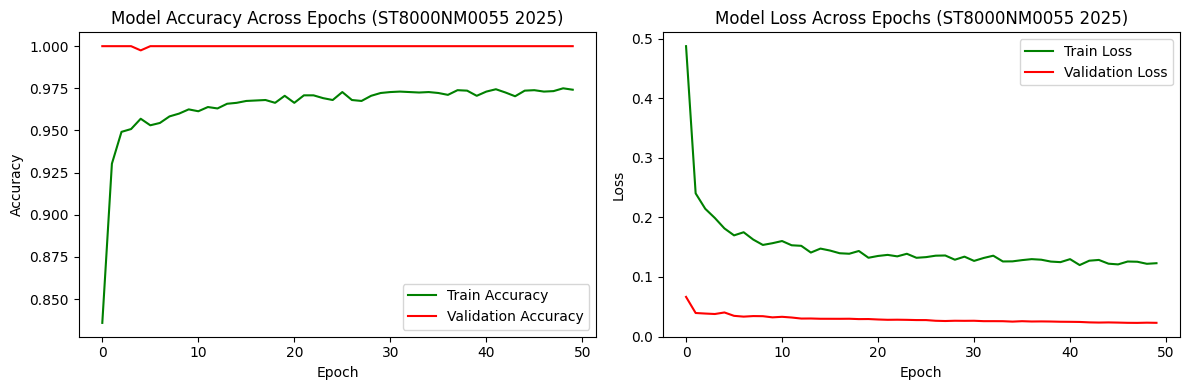

In [41]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], 'g', label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], 'r', label='Validation Accuracy')
ax1.set_title('Model Accuracy Across Epochs (ST8000NM0055 2025)')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='lower right')

ax2.plot(history.history['loss'], 'g', label='Train Loss')
ax2.plot(history.history['val_loss'], 'r', label='Validation Loss')
ax2.set_title('Model Loss Across Epochs (ST8000NM0055 2025)')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(file_directory, 'training_curves_ST8000NM0055_2025.png'), dpi=150)
plt.show()

# Evaluate the model on the 2025 Q3 test data

In [42]:
scores = model.evaluate(x_test_reshaped, y_test_reshaped, verbose=1)
print("Accuracy: %.2f%%, Mean Absolute Error: %.2f" % (scores[1] * 100, scores[2] * 100))

73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.9707 - loss: 0.1545 - mae: 0.0404
Accuracy: 97.07%, Mean Absolute Error: 4.04


In [43]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test_reshaped)
y_pred_binary = (y_pred > 0.5).astype(int)

print(classification_report(y_test_reshaped, y_pred_binary))

73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1160
           1       0.95      0.99      0.97      1160

    accuracy                           0.97      2320
   macro avg       0.97      0.97      0.97      2320
weighted avg       0.97      0.97      0.97      2320



## Additional metrics for the journal write-up

These weren't in the original notebook but are standard for the journal version and don't change the methodology — they just compute additional metrics from the same predictions.

In [44]:
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)

y_pred_proba = y_pred.flatten()

cm = confusion_matrix(y_test_reshaped, y_pred_binary)
print('Confusion matrix:')
print(cm)
print()

roc_auc = roc_auc_score(y_test_reshaped, y_pred_proba)
pr_auc  = average_precision_score(y_test_reshaped, y_pred_proba)
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC : {pr_auc:.4f}')

Confusion matrix:
[[1102   58]
 [  10 1150]]

ROC-AUC: 0.9963
PR-AUC : 0.9970


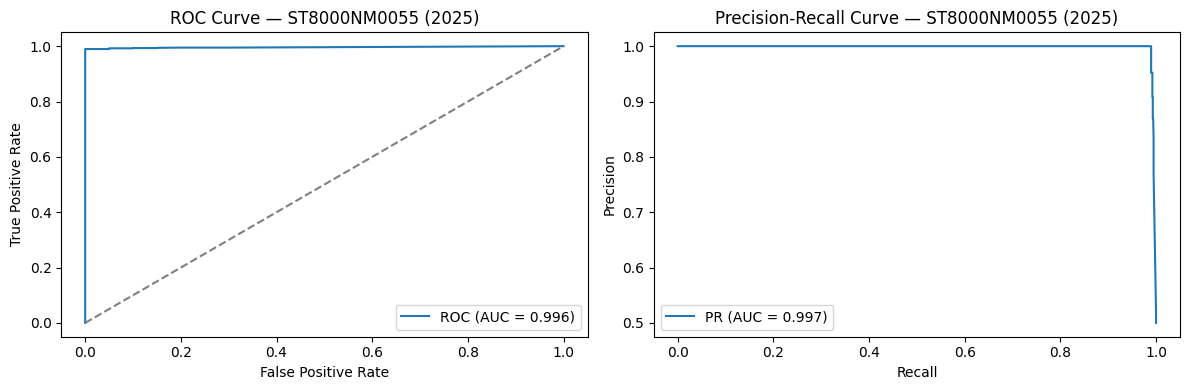

In [45]:
# Side-by-side ROC and PR curves for the paper figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

fpr, tpr, _ = roc_curve(y_test_reshaped, y_pred_proba)
ax1.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], '--', color='grey')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve — ST8000NM0055 (2025)')
ax1.legend()

precision, recall, _ = precision_recall_curve(y_test_reshaped, y_pred_proba)
ax2.plot(recall, precision, label=f'PR (AUC = {pr_auc:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve — ST8000NM0055 (2025)')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(file_directory, 'roc_pr_curves_ST8000NM0055_2025.png'), dpi=150)
plt.show()

## Summary table for the paper

Side-by-side comparison with the original 2020 ST8000NM0055 result (which you'll fill in from the 2020 notebook output).

In [46]:
summary = pd.DataFrame({
    'Metric':   ['Accuracy', 'Precision (class 0)', 'Recall (class 0)',
                 'Precision (class 1)', 'Recall (class 1)',
                 'F1 (class 0)', 'F1 (class 1)', 'ROC-AUC', 'PR-AUC'],
    '2020':     ['—', '—', '—', '—', '—', '—', '—', '—', '—'],   # fill from 2020 notebook
    '2025 Q3':  [
        f'{scores[1]*100:.2f}%',
        f'{precision_score(y_test_reshaped, y_pred_binary, pos_label=0):.2f}',
        f'{recall_score(y_test_reshaped, y_pred_binary, pos_label=0):.2f}',
        f'{precision_score(y_test_reshaped, y_pred_binary, pos_label=1):.2f}',
        f'{recall_score(y_test_reshaped, y_pred_binary, pos_label=1):.2f}',
        f'{f1_score(y_test_reshaped, y_pred_binary, pos_label=0):.2f}',
        f'{f1_score(y_test_reshaped, y_pred_binary, pos_label=1):.2f}',
        f'{roc_auc:.3f}',
        f'{pr_auc:.3f}',
    ],
})
print(summary.to_string(index=False))
summary.to_csv(os.path.join(file_directory, 'validation_summary_ST8000NM0055_2025.csv'), index=False)

             Metric 2020 2025 Q3
           Accuracy    —  97.07%
Precision (class 0)    —    0.99
   Recall (class 0)    —    0.95
Precision (class 1)    —    0.95
   Recall (class 1)    —    0.99
       F1 (class 0)    —    0.97
       F1 (class 1)    —    0.97
            ROC-AUC    —   0.996
             PR-AUC    —   0.997
